In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import skimage.io
import keras.backend as K
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout,BatchNormalization ,Activation
from tensorflow.keras.models import Model, Sequential
from keras.applications.nasnet import NASNetLarge
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam

In [2]:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   validation_split = 0.2,
                                  
        rotation_range=5,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        #zoom_range=0.2,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest')

valid_datagen = ImageDataGenerator(rescale = 1./255,
                                  validation_split = 0.2)

test_datagen  = ImageDataGenerator(rescale = 1./255
                                  )

In [4]:
train_dataset  = train_datagen.flow_from_directory(directory = "E:\\Capstone\\Dataset\\Gray_Img\\train",
                                                   target_size = (64,64),
                                                   class_mode = 'categorical',
                                                   subset = 'training',
                                                   batch_size = 32)

Found 12900 images belonging to 7 classes.


In [5]:
valid_dataset = valid_datagen.flow_from_directory(directory ="E:\\Capstone\\Dataset\\Gray_Img\\train",
                                                  target_size = (64,64),
                                                  class_mode = 'categorical',
                                                  subset = 'validation',
                                                  batch_size = 32)

Found 3225 images belonging to 7 classes.


In [6]:
test_dataset = test_datagen.flow_from_directory(directory = "E:\\Capstone\\Dataset\\Gray_Img\\test",
                                                  target_size = (64,64),
                                                  class_mode = 'categorical',
                                                  batch_size = 32)

Found 4032 images belonging to 7 classes.


In [7]:
num_features = 64  # or any other value you want
width = 64
height = 64
num_classes = 7  # or whatever the number of classes in your problem is



In [8]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Activation, Dropout, Flatten, Dense


In [9]:
base_model = tf.keras.applications.VGG16(input_shape=(64,64,3),include_top=False,weights="imagenet")

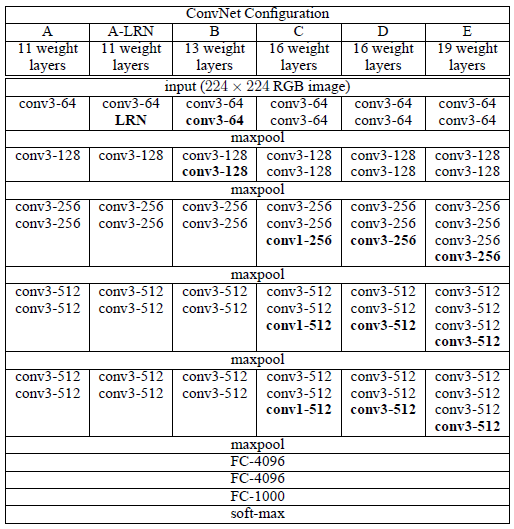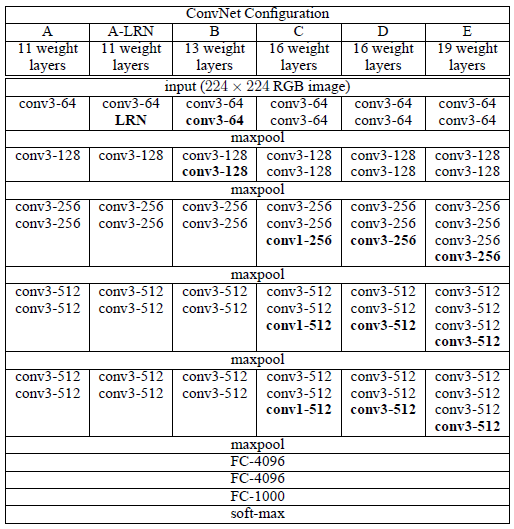

In [10]:
# Building Model

model=Sequential()
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.2))
model.add(Dense(4096,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1024,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(7,activation='softmax'))

In [11]:
# Model Summary
for layer in base_model.layers:
    layer.trainable=False
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 2, 2, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 2048)              0         
                                                                 
 dropout (Dropout)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 4096)              8392704   
                                                                 
 dropout_1 (Dropout)         (None, 4096)              0         
                                                                 
 dense_1 (Dense)             (None, 1024)              4195328   
                                                                 
 dropout_2 (Dropout)         (None, 1024)              0

In [12]:
print(base_model.layers[18].trainable)

False


In [13]:
def f1_score(y_true, y_pred): #taken from old keras source code
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())
    f1_val = 2*(precision*recall)/(precision+recall+K.epsilon())
    return f1_val

In [14]:
METRICS = [
      tf.keras.metrics.BinaryAccuracy(name='accuracy'),
      tf.keras.metrics.Precision(name='precision'),
      tf.keras.metrics.Recall(name='recall'),  
      tf.keras.metrics.AUC(name='auc'),
        f1_score,
]

In [15]:
lrd = ReduceLROnPlateau(monitor = 'val_loss',patience = 10,verbose = 1,factor = 0.50, min_lr = 1e-10)

mcp = ModelCheckpoint('vgg-16-model.h5')

es = EarlyStopping(verbose=1, patience=10)

In [16]:
model.compile(optimizer='Adam', loss='categorical_crossentropy',metrics=METRICS)

In [17]:
history=model.fit(train_dataset,validation_data=valid_dataset,epochs = 50,verbose = 1,callbacks=[lrd,mcp,es])

Epoch 1/50


404/404 [==============================] - ETA: 0s - loss: 1.8244 - accuracy: 0.8586 - precision: 0.5781 - recall: 0.0376 - auc: 0.6768 - f1_score: 0.0664

c:\Python10\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


404/404 [==============================] - 290s 711ms/step - loss: 1.8244 - accuracy: 0.8586 - precision: 0.5781 - recall: 0.0376 - auc: 0.6768 - f1_score: 0.0664 - val_loss: 2.0496 - val_accuracy: 0.8479 - val_precision: 0.3214 - val_recall: 0.0583 - val_auc: 0.5979 - val_f1_score: 0.0963 - lr: 0.0010
Epoch 2/50
404/404 [==============================] - 292s 723ms/step - loss: 1.5393 - accuracy: 0.8652 - precision: 0.6553 - recall: 0.1188 - auc: 0.7809 - f1_score: 0.1955 - val_loss: 1.8679 - val_accuracy: 0.8613 - val_precision: 0.6310 - val_recall: 0.0695 - val_auc: 0.6601 - val_f1_score: 0.1225 - lr: 0.0010
Epoch 3/50
404/404 [==============================] - 288s 713ms/step - loss: 1.3911 - accuracy: 0.8718 - precision: 0.6731 - recall: 0.2002 - auc: 0.8282 - f1_score: 0.3044 - val_loss: 2.0193 - val_accuracy: 0.8528 - val_precision: 0.4328 - val_recall: 0.0989 - val_auc: 0.6618 - val_f1_score: 0.1576 - lr: 0.0010
Epoch 4/50
404/404 [==============================] - 276s 683ms/s

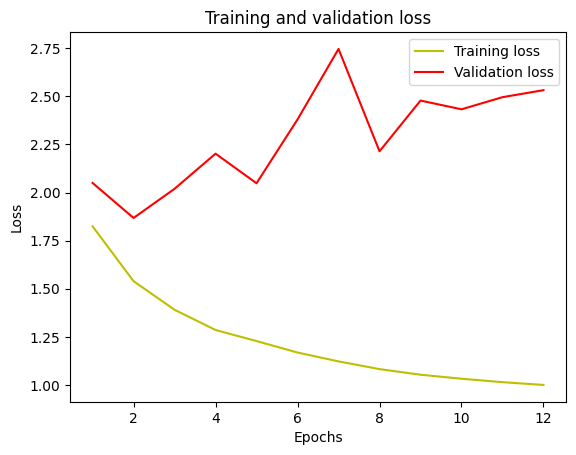

In [18]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

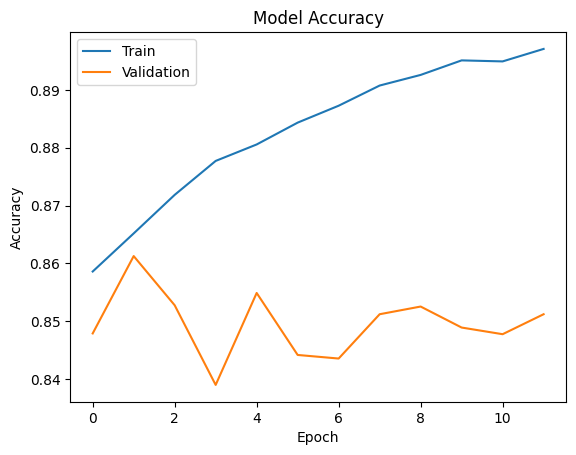

In [20]:
# Plot the training and validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

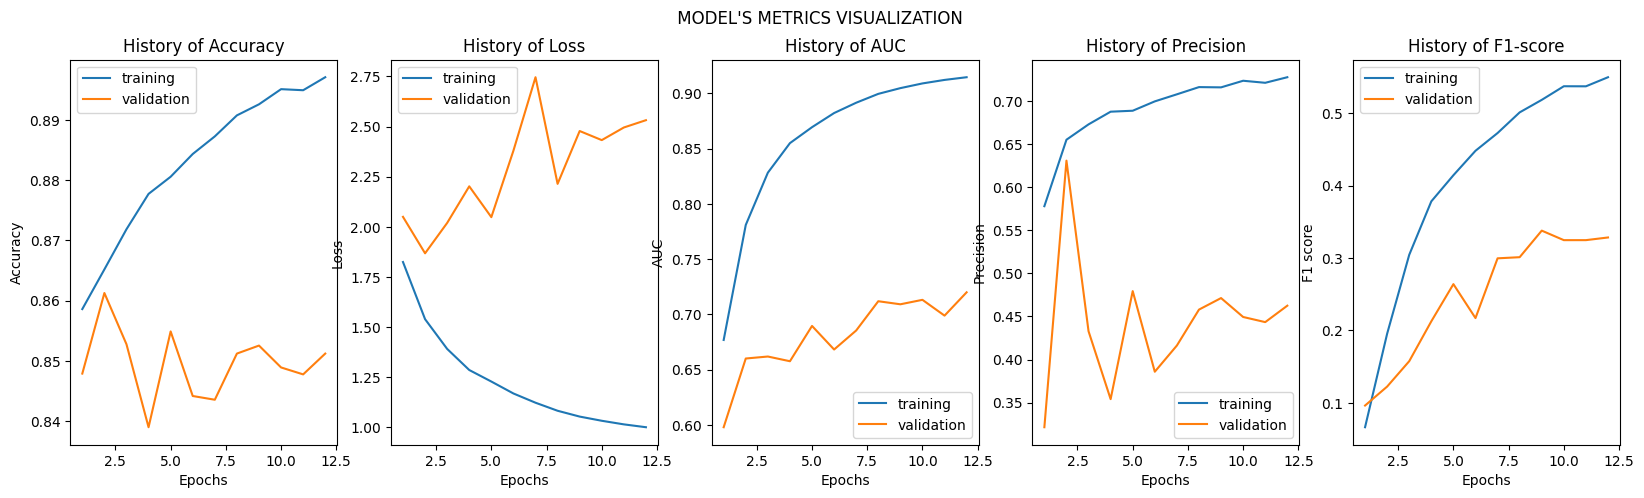

In [22]:
#%% PLOTTING RESULTS (Train vs Validation FOLDER 1)

def Train_Val_Plot(acc,val_acc,loss,val_loss,auc,val_auc,precision,val_precision,f1,val_f1):
    
    fig, (ax1, ax2,ax3,ax4,ax5) = plt.subplots(1,5, figsize= (20,5))
    fig.suptitle(" MODEL'S METRICS VISUALIZATION ")

    ax1.plot(range(1, len(acc) + 1), acc)
    ax1.plot(range(1, len(val_acc) + 1), val_acc)
    ax1.set_title('History of Accuracy')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend(['training', 'validation'])


    ax2.plot(range(1, len(loss) + 1), loss)
    ax2.plot(range(1, len(val_loss) + 1), val_loss)
    ax2.set_title('History of Loss')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend(['training', 'validation'])
    
    ax3.plot(range(1, len(auc) + 1), auc)
    ax3.plot(range(1, len(val_auc) + 1), val_auc)
    ax3.set_title('History of AUC')
    ax3.set_xlabel('Epochs')
    ax3.set_ylabel('AUC')
    ax3.legend(['training', 'validation'])
    
    ax4.plot(range(1, len(precision) + 1), precision)
    ax4.plot(range(1, len(val_precision) + 1), val_precision)
    ax4.set_title('History of Precision')
    ax4.set_xlabel('Epochs')
    ax4.set_ylabel('Precision')
    ax4.legend(['training', 'validation'])
    
    ax5.plot(range(1, len(f1) + 1), f1)
    ax5.plot(range(1, len(val_f1) + 1), val_f1)
    ax5.set_title('History of F1-score')
    ax5.set_xlabel('Epochs')
    ax5.set_ylabel('F1 score')
    ax5.legend(['training', 'validation'])


    plt.show()
    

Train_Val_Plot(history.history['accuracy'],history.history['val_accuracy'],
               history.history['loss'],history.history['val_loss'],
               history.history['auc'],history.history['val_auc'],
               history.history['precision'],history.history['val_precision'],
               history.history['f1_score'],history.history['val_f1_score']
              )

1/1 [==============================] - 1s 820ms/step
Accuracy =  0.3125


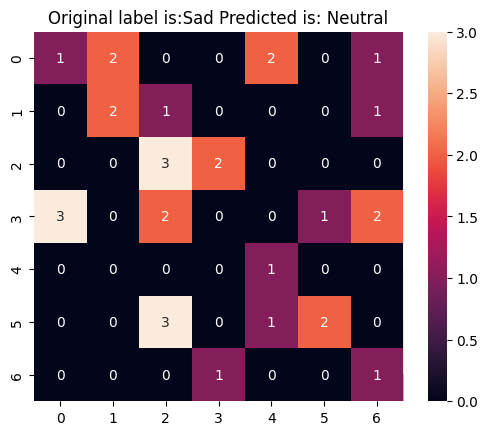

              precision    recall  f1-score   support

       angry       0.25      0.17      0.20         6
     disgust       0.50      0.50      0.50         4
        fear       0.33      0.60      0.43         5
       happy       0.00      0.00      0.00         8
     neutral       0.25      1.00      0.40         1
         sad       0.67      0.33      0.44         6
    surprise       0.20      0.50      0.29         2

    accuracy                           0.31        32
   macro avg       0.31      0.44      0.32        32
weighted avg       0.31      0.31      0.28        32



In [24]:
from sklearn.metrics import confusion_matrix, classification_report
from keras.models import load_model
import random
#Test the model
my_model = load_model('vgg-16-model.h5', compile=False)

#Generate a batch of images
test_img, test_lbl = valid_dataset.__next__()
predictions=my_model.predict(test_img)

predictions = np.argmax(predictions, axis=1)
test_labels = np.argmax(test_lbl, axis=1)

from sklearn import metrics
print ("Accuracy = ", metrics.accuracy_score(test_labels, predictions))

#Confusion Matrix - verify accuracy of each class
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, predictions)
#print(cm)
import seaborn as sns
sns.heatmap(cm, annot=True)

class_labels=['Angry','Disgust', 'Fear', 'Happy','Neutral','Sad','Surprise']
#Check results on a few select images
n=random.randint(0, test_img.shape[0] - 1)
image = test_img[n]
orig_labl = class_labels[test_labels[n]]
pred_labl = class_labels[predictions[n]]
plt.imshow(image[:,:,0], cmap='gray')
plt.title("Original label is:"+orig_labl+" Predicted is: "+ pred_labl)
plt.show()


class_names = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad','surprise']  # Replace with your actual class names
report = classification_report(test_labels, predictions, target_names=class_names, labels=range(len(class_names)))
print(report)